
## TIMELINEDATATRAN - DADOS DE ACIDENTE DE TRANSITO, INFERENCIA

**Aluno:** Lucas Antonio Cunha Rodrigues da Silva / Marcos Beregula  
**Curso:** Ciência de Dados e IA – 3º ano   
**Disciplina:** Integração e preparação de dados  
**Professor:** Daniel dos Santos Kaster  
**Instituição:** Universidade Estadual de Londrina (UEL)    
**Data:** 26/06/2026    

# Objetivo:
**O objetivo desta atividade é ,através do datawarehouse estabelecido na primeira** 
**atividade, realizar o processo de engenharia de atributos e usando técnicas de** 
**aprendizado supervisionado prever informações de acordo com a nossa base de dados.**
**OBJETIVO:**
**"Estimar a probabilidade de um acidente resultar em óbito a partir de suas**
**características espaciais, temporais e ambientais."**

# 1. IMPORTÇÃO DAS BIBLIOTECAS

In [50]:
import pandas as pd
import psycopg2
from sqlalchemy import create_engine
from dotenv import load_dotenv
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


# 1.1 - Ajustando as configurações para visualizar todos os dados

In [65]:
# todas as colunas
pd.set_option('display.max_columns', None)

# largura da tabela
pd.set_option('display.width', None)

# Não truncar o conteúdo das células
pd.set_option('display.max_colwidth', None)

# Não quebrar DataFrames em várias "páginas"
pd.set_option('display.expand_frame_repr', False)

# 2 - CONEXAO COM BANCO DE DADOS (DATAWAREHOUSE) PRA OBTENCAO DOS DADOS:
**Criação de um dataframe com todas as informações:**

In [2]:
#NAO PRECISA RODAR JA FIZEMOS A LEITURA DO BANCO E PERSISTENCIA!!!!
conexao = psycopg2.connect(
    host="aws-1-sa-east-1.pooler.supabase.com",
    database="postgres",
    user="postgres.daaieslttburjfmsldsv",
    password="supabasekaster",
    port="5432"
)

query = """
SELECT
    f.fato_id,
    f.id_acidente,
    f.data_acidente,

    -- Métricas da fato
    f.pessoas,
    f.mortos,
    f.feridos_leves,
    f.feridos_graves,
    f.ilesos,
    f.ignorados,
    f.feridos,
    f.veiculos,
    f.fase_dia,

    -- Calendário
    c.ano,
    c.mes,
    c.dia,
    c.nome_mes,
    c.trimestre,
    c.dia_semana,
    c.nome_dia_semana,
    c.eh_fim_semana,

    -- Município
    m.nome_municipio,
    m.nome_microrregiao,
    m.nome_mesorregiao,
    m.sigla_uf,
    m.nome_uf,
    m.nome_regiao,

    -- Localização
    l.br,
    l.km,

    -- Condições da via
    v.condicao_metereologica,
    v.tipo_pista,
    v.tracado_via,
    v.sentido_via,

    -- Acidente
    a.causa_acidente,
    a.tipo_acidente,
    a.classificacao_acidente,

    -- Feriado
    fe.nome_feriado,
    fe.tipo_feriado

FROM dw.fato_acidentes_datatran f

LEFT JOIN dw.dim_calendario c
    ON f.data_acidente = c.data

LEFT JOIN dw.dim_municipios m
    ON f.id_municipio = m.id_municipio

LEFT JOIN dw.dim_localizacao l
    ON f.localizacao_id = l.localizacao_id

LEFT JOIN dw.dim_condicao_via v
    ON f.condicao_id = v.condicao_id

LEFT JOIN dw.dim_acidente a
    ON f.acidente_dim_id = a.acidente_dim_id

LEFT JOIN dw.dim_feriados fe
    ON f.id_feriado = fe.id_feriado;
"""

df = pd.read_sql_query(query, conexao)

conexao.close()

print(df.info())
print(df.head())

df.to_csv(
    "timelinedatatran.csv",
    index=False,
    encoding="utf-8-sig"
    #encoding pra evitar problemas com acentuação
)

/var/folders/54/fr9l7bd94ng5bc0gv_kvlsvh0000gn/T/ipykernel_12076/926945266.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conexao)


KeyboardInterrupt: 

# 2.1 - Enriquecimento e tratamento no OPENREFINE:

**Realizamos a verificação da presença de clusters pra ver se havia duplicatas**
**indevidas e também algumas correções pontuais**

*Feriados de aniversarios de cidades transformados em municipais:*

*if(  
  isBlank(cells["nome_feriado"].value),  
  value,  
  if(  
    cells["nome_feriado"].value.toString().toLowercase().contains("anivers"),  
    "Municipal",  
    value  
  )  
)* 

**Excluidas 5511 observações que apresentavam condição metereológica "IGNORADO ou Ignorado"**

**Excluidas 887 observações que apresentavam SENTIDO_VIA "Não Informado"**

**Alguns clusters foram encontrados:**
**Assim foi possível deixar o dataset condizente com oque buscávamos**

![exemplo clusters](/clusters.png)

# 2.2 - Abrindo o dataset LIMPO adicionando nossa coluna target, DUMMY SE MORTE 
**VAMOS PROCURAR SABER A PROPORCAO (PROBABILIDADE DE OBTIDO CONFORME LOCAL E DATA)**

In [51]:
df_clean = pd.read_csv("timelinedatatranClean.csv")
#verificando se temos valores nulos na coluna pessoas pra evitar divisão por zero
print((df_clean["pessoas"] == 0).sum())

#criando nova feature indice_fatalidade
df_clean["indice_fatalidade"] = df_clean["mortos"]/df_clean["pessoas"]
#truncando o km pra poder criar grupos mais consistentes nao precisamos da granularidade
#de centenas de metros

df_clean["km"] = np.floor(df_clean["km"]).astype(int)

#criando variavel dummy para target (ocorrencia de morte)
df_clean["target_obito"] = np.where(
    df_clean["mortos"] > 0,
    1,
    0
)
df_clean.head()

# garantir data como datetime
df_clean["data_acidente"] = pd.to_datetime(df_clean["data_acidente"])

df_clean.info()
df_clean.head()

/var/folders/54/fr9l7bd94ng5bc0gv_kvlsvh0000gn/T/ipykernel_12076/1781738290.py:1: DtypeWarning: Columns (34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("timelinedatatranClean.csv")


0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390977 entries, 0 to 390976
Data columns (total 39 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   fato_id                 390977 non-null  int64         
 1   id_acidente             390977 non-null  int64         
 2   data_acidente           390977 non-null  datetime64[ns]
 3   pessoas                 390977 non-null  int64         
 4   mortos                  390977 non-null  int64         
 5   feridos_leves           390977 non-null  int64         
 6   feridos_graves          390977 non-null  int64         
 7   ilesos                  390977 non-null  int64         
 8   feridos                 390977 non-null  int64         
 9   veiculos                390977 non-null  int64         
 10  fase_dia                390977 non-null  object        
 11  ano                     390977 non-null  int64         
 12  mes                     3909

,fato_id,id_acidente,data_acidente,pessoas,mortos,feridos_leves,feridos_graves,ilesos,feridos,veiculos,...,tracado_via,sentido_via,causa_acidente,tipo_acidente,classificacao_acidente,nome_feriado,tipo_feriado,feriado,indice_fatalidade,target_obito
0,10,190021,2019-02-07,3,0,1,0,2,1,3,...,Reta,Crescente,Ingestão de Álcool,Colisão frontal,Com Vítimas Feridas,0,0,0,0.0,0
1,19,196789,2019-03-13,3,0,1,0,1,1,3,...,Reta,Decrescente,Falta de Atenção à Condução,Colisão traseira,Com Vítimas Feridas,0,0,0,0.0,0
2,31,105086,2018-01-21,1,0,0,0,0,0,1,...,Reta,Crescente,Falta de Atenção à Condução,Saída de leito carroçável,Sem Vítimas,0,0,0,0.0,0
3,34,112918,2018-02-21,2,0,1,0,1,1,2,...,Reta,Crescente,Falta de Atenção à Condução,Colisão traseira,Com Vítimas Feridas,0,0,0,0.0,0
4,35,146218,2018-07-12,5,0,2,0,3,2,2,...,Reta,Crescente,Falta de Atenção à Condução,Colisão lateral,Com Vítimas Feridas,0,0,0,0.0,0


# 2.3 - Vamos conversar com os dados?
**Nossa ideia inicial era agrupar por data local e fase do dia**
**abaixo fica demonstrado que essa agregação pouco muda a representação do problema**

**Alguns testes apontaram que pouco mudou a representação pela agregação**

**data + municipio + fase_dia = 90%**

**data + municipio = 83%**



In [52]:
# verificar se agrupando por municipio, data e fase do dia é uma boa ideia
grupos = (
    df_clean
    .groupby(["nome_municipio", "data_acidente", "fase_dia"])
    .size()
)

print(grupos.value_counts().sort_index())

#saimos de 351k linhas para 319k linhas, entao vemos que a nova representação não funciona idealmente.


#As situacão acima nao reduziu a quantidade de observacoes oque faz com que a
#agregacao por municipio, data e fase do dia nao seja uma boa ideia.
#vamos tentar outra abordagem:
#local = municipio + br + km
#momento = data + fase_dia + feriado + dia da semana
#vamos ver se essa nova representacao consegue reduzir a quantidade de observacoes
#vamos agrupar por local e momento e ver se a quantidade de observacoes é menor
grupos_3 = (
    df_clean
    .groupby(["nome_municipio", "br", "km", "data_acidente", "fase_dia", "feriado", "dia_semana"])
    .size()
)

print(grupos_3.value_counts().sort_index())

1    319392
2     26899
3      4208
4       910
5       212
6        56
7        17
8         1
Name: count, dtype: int64
1    383095
2      3787
3        96
4         5
Name: count, dtype: int64


# 2.4 - Definindo as variaveis a serem consideradas no modelo
**para usarmos todas as variaveis fornecidas pelo dataset resolvemos deixar as**
**colunas informativas como tipo de colisão, causa, quantidade de veículos e etc.**


In [53]:
# colunas que vamos manter como features
features = [
    # LOCAL
    "nome_municipio",
    "sigla_uf",
    "nome_regiao",
    "br",
    "km",

    # MOMENTO
    "ano",
    "mes",
    "dia",
    "trimestre",
    "dia_semana",
    "eh_fim_semana",
    "fase_dia",

    # FERIADO
    "feriado",
    "tipo_feriado",

    # CLIMA/AMBIENTE
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "sentido_via",
    "causa_acidente",
    "tipo_acidente",
    "veiculos",
    "pessoas"
]

target = "target_obito"

df_ml = df_clean[features + [target]].copy()

df_ml.info()
df_ml.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390977 entries, 0 to 390976
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   nome_municipio          390977 non-null  object
 1   sigla_uf                390977 non-null  object
 2   nome_regiao             390977 non-null  object
 3   br                      390977 non-null  int64 
 4   km                      390977 non-null  int64 
 5   ano                     390977 non-null  int64 
 6   mes                     390977 non-null  int64 
 7   dia                     390977 non-null  int64 
 8   trimestre               390977 non-null  int64 
 9   dia_semana              390977 non-null  int64 
 10  eh_fim_semana           390977 non-null  bool  
 11  fase_dia                390977 non-null  object
 12  feriado                 390977 non-null  int64 
 13  tipo_feriado            390977 non-null  object
 14  condicao_metereologica  390977 non-n

,nome_municipio,sigla_uf,nome_regiao,br,km,ano,mes,dia,trimestre,dia_semana,...,tipo_feriado,condicao_metereologica,tipo_pista,tracado_via,sentido_via,causa_acidente,tipo_acidente,veiculos,pessoas,target_obito
0,Rio Branco,AC,Norte,364,111,2019,2,7,1,4,...,0,Nublado,Simples,Reta,Crescente,Ingestão de Álcool,Colisão frontal,3,3,0
1,Rio Branco,AC,Norte,364,122,2019,3,13,1,3,...,0,Nublado,Dupla,Reta,Decrescente,Falta de Atenção à Condução,Colisão traseira,3,3,0
2,Rio Branco,AC,Norte,364,126,2018,1,21,1,7,...,0,Chuva,Simples,Reta,Crescente,Falta de Atenção à Condução,Saída de leito carroçável,1,1,0
3,Rio Branco,AC,Norte,364,126,2018,2,21,1,3,...,0,Céu Claro,Simples,Reta,Crescente,Falta de Atenção à Condução,Colisão traseira,2,2,0
4,Rio Branco,AC,Norte,364,126,2018,7,12,3,4,...,0,Céu Claro,Simples,Reta,Crescente,Falta de Atenção à Condução,Colisão lateral,2,5,0


## 2.5 - Checando balanceamento

In [54]:
#VERIFICANDO o balanceamento da variavel target
print(df_ml["target_obito"].value_counts())

percentual_obitos = (
    df_ml["target_obito"].value_counts() / len(df_ml)
) * 100

print(percentual_obitos)

#93% dos acidentes nao resultaram em óbito

#como queremos a probabilidade vamos manter a proporcao.

#os algoritmos XGboost e LightGBM podem ser informados que a classe 1 é rara!




target_obito
0    363714
1     27263
Name: count, dtype: int64
target_obito
0    93.026956
1     6.973044
Name: count, dtype: float64


## 3 - Preparação para o modelo
**Separando features de rótulos, capturando as descritivas e criando categorias**

In [55]:
X = df_ml.drop(columns=["target_obito"])
y = df_ml["target_obito"]
print(X.shape)
print(y.shape)

#Verificando quais categorias sao descritivas (categoricas), já sabemos apenas capturando.

cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(cat_features)

#Para o LightGBM transformamos em categoria:

for col in cat_features:
    X[col] = X[col].astype("category")



(390977, 22)
(390977,)
['nome_municipio', 'sigla_uf', 'nome_regiao', 'fase_dia', 'tipo_feriado', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'sentido_via', 'causa_acidente', 'tipo_acidente']


## Separação treino/teste
**Temos dados 6 anos, deixaremos 2023 pra teste e os demais (18,19,20,21,22) para treino**
**capturando os pesos das classes para passar pro modelo**


In [56]:
X_train = X[X["ano"] < 2023]
X_test = X[X["ano"] == 2023]

y_train = y[X["ano"] < 2023]
y_test = y[X["ano"] == 2023]

print(X_train.shape)
print(X_test.shape)

negativa = (y_train == 0).sum()
positiva = (y_train == 1).sum()

peso = negativa / positiva

print(peso)




(324223, 22)
(66754, 22)
13.415677382063937


## 4 - Declarando o modelo de aprendizado

In [57]:
#testar balanceado e sem equilibrio pra ver o impacto
modelo = LGBMClassifier(

    objective="binary",

    n_estimators=300,

    learning_rate=0.05,

    num_leaves=31,

    random_state=42,

    scale_pos_weight=peso,
#testar com balanced pra ver a diferenca

    #class_weight="balanced"
)

**4.1 - treinamento, tiramos a coluna ano pois os grupos ja estao segregados por ano**

In [58]:
X_train = X_train.drop(columns=["ano"])
X_test = X_test.drop(columns=["ano"])
modelo.fit(
    X_train,
    y_train,
    categorical_feature=cat_features
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 22491, number of negative: 301732
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2391
[LightGBM] [Info] Number of data points in the train set: 324223, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.069369 -> initscore=-2.596424
[LightGBM] [Info] Start training from score -2.596424


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# 4.2 - Teste - Obtendo o vetor de probabilidades de resultar em obtito e as classes

In [59]:
probabilidades = modelo.predict_proba(X_test)[:, 1]

#predict padrao ja usa o threshold de 0.5 pra definir a classe
#verificar se da pra melhorar isso aqui deixar mais soft


classes = modelo.predict(X_test)

# 5 - Metricas de avaliação

In [60]:
#ACURACIA
acc = accuracy_score(y_test, classes)

print(f"Acurácia: {acc:.4f}")

#ROC-AUC
auc = roc_auc_score(y_test, probabilidades)

print(f"ROC-AUC: {auc:.4f}")

#PRECISION E RECALL

print(classification_report(y_test, classes))

#CONFUSION MATRIX

cm = confusion_matrix(y_test, classes)

print(cm)

Acurácia: 0.8021
ROC-AUC: 0.8180
              precision    recall  f1-score   support

           0       0.97      0.81      0.88     61982
           1       0.22      0.67      0.33      4772

    accuracy                           0.80     66754
   macro avg       0.59      0.74      0.60     66754
weighted avg       0.92      0.80      0.84     66754

[[50356 11626]
 [ 1582  3190]]


# Visualização da matriz de confusão
#aqui nem sei se vale a pena errando bem em classes né talvez threshold verificar soft

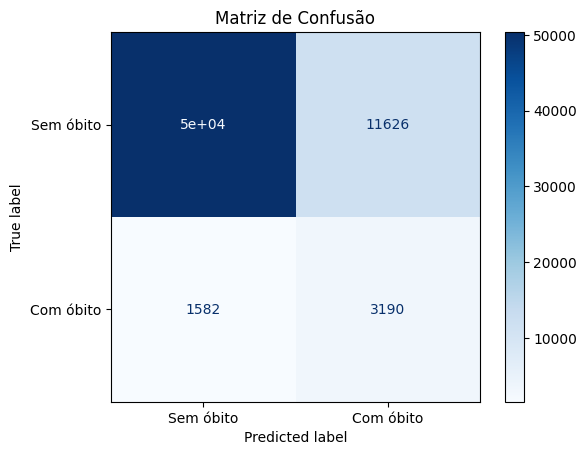

In [61]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sem óbito", "Com óbito"]
)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusão")
plt.show()

## MOSTRANDO AS 20 MAIORES PROBABILIDADES DE OBTIDO PARA ACIDENTES, AREAS MAIS PERIGOSAS

In [66]:
resultado = X_test.copy()

resultado["Probabilidade_Obito"] = probabilidades

resultado["Real"] = y_test.values

resultado = resultado.sort_values(
    "Probabilidade_Obito",
    ascending=False
)

resultado.head(20)

,nome_municipio,sigla_uf,nome_regiao,br,km,mes,dia,trimestre,dia_semana,eh_fim_semana,fase_dia,feriado,tipo_feriado,condicao_metereologica,tipo_pista,tracado_via,sentido_via,causa_acidente,tipo_acidente,veiculos,pessoas,Probabilidade_Obito,Real
161468,Várzea Alegre,CE,Nordeste,230,81,2,19,1,7,True,Plena Noite,0,0,Céu Claro,Simples,Reta,Crescente,Acessar a via sem observar a presença dos outros veículos,Atropelamento,2,2,0.980824,0
388988,Araripina,PE,Nordeste,316,17,12,15,4,5,False,Plena Noite,1,Municipal,Céu Claro,Simples,Aclive;Reta,Crescente,Transitar em local proibido,Colisão frontal,2,37,0.980604,0
60574,Várzea Alegre,CE,Nordeste,230,77,11,28,4,2,False,Plena Noite,0,0,Céu Claro,Simples,Reta;Aclive,Decrescente,Transitar em local proibido,Colisão frontal,2,2,0.980382,1
171384,Gaspar,SC,Sul,470,45,8,4,3,5,False,Amanhecer,0,0,Céu Claro,Simples,Curva;Em Obras,Crescente,Transitar em local proibido,Colisão frontal,3,13,0.977925,1
201393,Bacabal,MA,Nordeste,316,368,8,5,3,6,True,Plena Noite,1,Municipal,Céu Claro,Simples,Reta,Decrescente,Transitar em local proibido,Colisão frontal,4,4,0.977453,0
167015,Uruaçu,GO,Centro-Oeste,153,205,7,3,3,1,False,Amanhecer,0,0,Céu Claro,Simples,Aclive,Crescente,Transitar em local proibido,Colisão frontal,6,52,0.977025,1
292160,Aparecida,SP,Sudeste,116,75,12,4,4,1,False,Amanhecer,1,Municipal,Céu Claro,Dupla,Reta,Crescente,pedestre na via,Atropelamento,5,5,0.976486,1
350208,Várzea Alegre,CE,Nordeste,230,83,10,20,4,5,False,Amanhecer,0,0,Céu Claro,Simples,Reta,Crescente,Transitar em local proibido,Colisão frontal,2,2,0.975840,1
70874,São José dos Pinhais,PR,Sul,116,97,4,16,2,7,True,Amanhecer,0,0,Chuva,Dupla,Reta,Decrescente,pedestre na via,Atropelamento,4,5,0.975665,1
200340,Lagoa Grande,MG,Sudeste,40,98,2,11,1,6,True,Amanhecer,1,Municipal,Céu Claro,Simples,Reta,Crescente,Transitar em local proibido,Colisão frontal,4,22,0.974798,1
